# **Creditworthiness Prediction for Credit Card Issuance**

Sei stato assunto dalla **Pro National Bank** come data scientist, e il tuo primo incarico consiste nel realizzare un **modello in grado di stimare l'affidabilità creditizia dei clienti**, al fine di aiutare il team dedicato a comprendere se accettare o meno la richiesta per il rilascio della carta di credito.

Ti vengono consegnati i dati anonimizzati di clienti che hanno già ottenuto la carta di credito e ne pagano regolarmente le rate. I dati contengono le informazioni dei correntisti che hanno richiesto l’apertura di una linea di credito.

**DATASET**

---
La banca ha fornito un dataset anonimizzato contenente informazioni socio‑demografiche, lavorative e comportamentali dei correntisti che hanno già richiesto una carta di credito.

I dati sono disponibili in un file CSV che puoi scaricare da questo indirizzo: </br>
[credit_scoring.csv](https://proai-datasets.s3.eu-west-3.amazonaws.com/credit_scoring.csv)



---

**Colonne del dataset**
- **ID**: numero identificativo del cliente
- **CODE_GENDER**: sesso del cliente
- **FLAGOWNCAR**: indicatore del possesso di un'automobile
- **FLAGOWNREALTY**: indicatore del possesso di una casa
- **CNT_CHILDREN**: numero di figli
- **AMTINCOMETOTAL**: reddito annuale
- **NAMEINCOMETYPE**: tipo di reddito
- **NAMEEDUCATIONTYPE**: livello di educazione
- **NAMEFAMILYSTATUS**: stato civile
- **NAMEHOUSINGTYPE**: tipo di abitazione
- **DAYS_BIRTH**: numero di giorni trascorsi dalla nascita
- **DAYS_EMPLOYED**: numero di giorni trascorsi dalla data di assunzione (se positivo, indica il numero di giorni da quando è disoccupato)
- **FLAG_MOBIL**: indicatore della presenza di un numero di cellulare
- **FLAGWORKPHONE**: indicatore della presenza di un numero di telefono di lavoro
- **FLAG_PHONE**: indicatore della presenza di un numero di telefono
- **FLAG_EMAIL**: indicatore della presenza di un indirizzo email
- **OCCUPATION_TYPE**: tipo di occupazione
- **CNTFAMMEMBERS**: numero di familiari
- **TARGET**: variabile che vale 1 se il cliente ha una elevata affidabilità creditizia (pagamento costante delle rate), 0 altrimenti.


## **OBIETTIVO DEL PROGETTO**

L’obiettivo è costruire un modello di classificazione che, a partire dalle caratteristiche del cliente, **preveda il valore della variabile TARGET**. </br>
In altre parole, il modello deve stimare se un nuovo richiedente ha una buona affidabilità creditizia.

# **1. ESPLORAZIONE DEL DATASET**

Questa sezione ha l’obiettivo di comprendere la struttura del dataset, identificare eventuali criticità e preparare le trasformazioni necessarie per la fase di preprocessing. </br>
Nel dettaglio,in questa sezione devo capire:
- come è composto il dataset
- quali tipi di variabili contiene e se tra queste ci sono alcuni poco utili
- se ci sono valori mancanti
- comprendere la distribuzione della variabile target : `TARGET`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
RANDOM_SEED=0

## **1.1 Caricamento Dati e prima analisi del dataset**

In [ ]:
df=pd.read_csv('credit_scoring.csv')
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,-11778.0,-4438.0,1.0,1.0,0.0,0.0,NaN,2.0,0
1,5008805,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,-11777.0,-4459.0,1.0,1.0,0.0,0.0,NaN,2.0,0
2,5008806,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,-21471.0,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-18489.0,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
4,5008809,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19093.0,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1


In [ ]:
print("DIMENSIONI DATASET Credit-Worthiness")
print(f"ROWS={df.shape[0]}")
print(f"COLUMNS={df.shape[1]}")

DIMENSIONI DATASET Credit-Worthiness
ROWS=338427
COLUMNS=19


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338427 entries, 0 to 338426
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   338427 non-null  int64  
 1   CODE_GENDER          338427 non-null  object 
 2   FLAG_OWN_CAR         338427 non-null  object 
 3   FLAG_OWN_REALTY      338427 non-null  object 
 4   CNT_CHILDREN         338427 non-null  int64  
 5   AMT_INCOME_TOTAL     338427 non-null  float64
 6   NAME_INCOME_TYPE     338427 non-null  object 
 7   NAME_EDUCATION_TYPE  338427 non-null  object 
 8   NAME_FAMILY_STATUS   338426 non-null  object 
 9   NAME_HOUSING_TYPE    338426 non-null  object 
 10  DAYS_BIRTH           338426 non-null  float64
 11  DAYS_EMPLOYED        338426 non-null  float64
 12  FLAG_MOBIL           338426 non-null  float64
 13  FLAG_WORK_PHONE      338426 non-null  float64
 14  FLAG_PHONE           338426 non-null  float64
 15  FLAG_EMAIL       

In [ ]:
df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,TARGET
count,3.384270e+05,338427.000000,3.384270e+05,338426.000000,338426.000000,338426.0,338426.000000,338426.000000,338426.000000,338426.000000,338427.000000
mean,5.821200e+06,0.428934,1.876685e+05,-15998.212897,60234.533869,1.0,0.211379,0.293302,0.105181,2.197228,0.087824
std,4.517704e+05,0.727990,1.107863e+05,4193.088539,138522.923248,0.0,0.408287,0.455276,0.306787,0.899570,0.283039
min,5.008804e+06,0.000000,2.554898e+04,-26636.000000,-17973.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
25%,5.439602e+06,0.000000,1.212299e+05,-19467.000000,-3116.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
50%,5.878907e+06,0.000000,1.628553e+05,-15623.000000,-1483.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
75%,6.140206e+06,1.000000,2.252082e+05,-12516.250000,-378.000000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000
max,6.841875e+06,19.000000,7.071016e+06,-7566.000000,396498.000000,1.0,1.000000,1.000000,1.000000,20.000000,1.000000


Dalla prima analisi noto che il dataset contiene sia variabili numeriche sia variabili categoriche. </br>
Le principali variabili categoriche sono: `CODE_GENDER`, `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`, `NAME_INCOME_TYPE`, `NAME_EDUCATION_TYPE`, `NAME_FAMILY_STATUS`, `NAME_HOUSING_TYPE`, `OCCUPATION_TYPE`. <br>
Queste variabili dovranno essere trasformate in numeriche tramite encoding.                       

## **1.2 Analisi della variabile Target**

In [ ]:
df['TARGET'].value_counts(normalize=True)

,proportion
TARGET,
0,0.912176
1,0.087824


**NOTA** </br>
La variabile `TARGET` è sbilanciata:
- la maggior parte dei clienti ha TARGET = 0 (non affidabile)

Nella fase di modellazione sarà quindi utile considerare tecniche di bilanciamento come:
- class_weight= 'balanced'
- undesampling

## **1.3 Controllo Duplicati**

In [ ]:
# check duplicati
duplicates = df.duplicated().sum()
print("Numero di righe duplicate:", duplicates)

Numero di righe duplicate: 0


Il dataset non contiene righe duplicate, quindi non è necessario rimuovere osservazioni.

## **1.4 Analisi dei valori mancanti**

Controllo la presenza di valori mancanti in ciascuna colonna per capire quali variabili richiedono attenzione. </br>
Questo mi permette di capire se i valori mancanti sono distribuiti normalmente nel dataset oppure se esiste una riga particolarmente incompleta.

In [ ]:
# check valori mancanti
df.isna().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,1
NAME_HOUSING_TYPE,1


Dall’analisi emerge una sola riga con valori mancanti da rimuovere.

In [ ]:
df[df["NAME_FAMILY_STATUS"].isna()]

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
338426,6392180,F,N,N,0,68765.48,Working,Secondary / se,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
df.dropna(subset=["NAME_FAMILY_STATUS"], inplace=True)
df.isna().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


Nonostante l'eliminazione della riga con diversi valori mancanti, è ancora presente la feature `OCCUPATION_TYPE`, contraddistinta dal 30% di valori mancanti.

In [ ]:
missing_values = df.isna().sum()

missing_percentage = (
    missing_values / len(df) * 100
).sort_values(ascending=False)

missing_percentage

,0
OCCUPATION_TYPE,30.535774
CODE_GENDER,0.000000
ID,0.000000
FLAG_OWN_CAR,0.000000
FLAG_OWN_REALTY,0.000000
AMT_INCOME_TOTAL,0.000000
CNT_CHILDREN,0.000000
NAME_EDUCATION_TYPE,0.000000
NAME_FAMILY_STATUS,0.000000
NAME_HOUSING_TYPE,0.000000


Per evitare di perdere troppe informazioni, sostituisco i valori mancanti con `"Unknown"`.

In [ ]:
df['OCCUPATION_TYPE']= df['OCCUPATION_TYPE'].fillna("Unknown")

## **1.5 Eliminazione feature inutili**

Qui faccio 2 operazioni utili per la fase di modellazione:
- Rimuovo la colonna `ID`, non informativa
- Trasformo `DAYS_BIRTH` in una variabile età più intuitiva.
- Correggo l'outlier in `DAYS_EMPLOYED` : dato che il valore 365243 è un outlier perchè indica o una occupazione da tempo particolarmente lungo o un errore -> quindi lo annulliamo.

In [ ]:
df = df.drop("ID", axis=1)
df["AGE"] = -df["DAYS_BIRTH"] / 365

In [ ]:
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, 0)

In [ ]:
df = df.drop("DAYS_BIRTH", axis=1)

In [ ]:
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE
0,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,-4438.0,1.0,1.0,0.0,0.0,Unknown,2.0,0,32.268493
1,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,-4459.0,1.0,1.0,0.0,0.0,Unknown,2.0,0,32.265753
2,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0,58.824658
3,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1,50.654795
4,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1,52.309589


## **1.6 Analisi delle variabili categoriche**

In [ ]:
categorical_cols = [
    "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"
]

Controllo il numero di categorie per ogni variabile

In [ ]:
for column in categorical_cols:
    print(column)
    print("Numero di categorie:", df[column].nunique(dropna=False))
    print(df[column].value_counts(dropna=False))
    print("-" * 50)

CODE_GENDER
Numero di categorie: 2
CODE_GENDER
F    227915
M    110511
Name: count, dtype: int64
--------------------------------------------------
FLAG_OWN_CAR
Numero di categorie: 2
FLAG_OWN_CAR
N    213195
Y    125231
Name: count, dtype: int64
--------------------------------------------------
FLAG_OWN_REALTY
Numero di categorie: 2
FLAG_OWN_REALTY
Y    231307
N    107119
Name: count, dtype: int64
--------------------------------------------------
NAME_INCOME_TYPE
Numero di categorie: 5
NAME_INCOME_TYPE
Working                 174365
Commercial associate     78090
Pensioner                57841
State servant            28113
Student                     17
Name: count, dtype: int64
--------------------------------------------------
NAME_EDUCATION_TYPE
Numero di categorie: 5
NAME_EDUCATION_TYPE
Secondary / secondary special    232568
Higher education                  91062
Incomplete higher                 11387
Lower secondary                    3177
Academic degree                   

**NOTA**: </br>
In fase di Preprocessing :
- Le variabili binarie (`CODE_GENDER`, `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`) -> LabelEncoder
- Le variabili multicategoria -> OneHotEncoder.
- `OCCUPATION_TYPE` ha molte categorie -> carefull alla dimensionalità.

## **1.7 Analisi Grafica**

---
Per completare l’esplorazione iniziale, analizzo graficamente alcune variabili che possono essere utili per descrivere i clienti del dataset:</br>

▶ **Distribuzione Età**</br>
▶ **Distribuzione reddito**</br>
▶ **Numero figli**</br>
▶ **Distribuzione TARGET**</br>


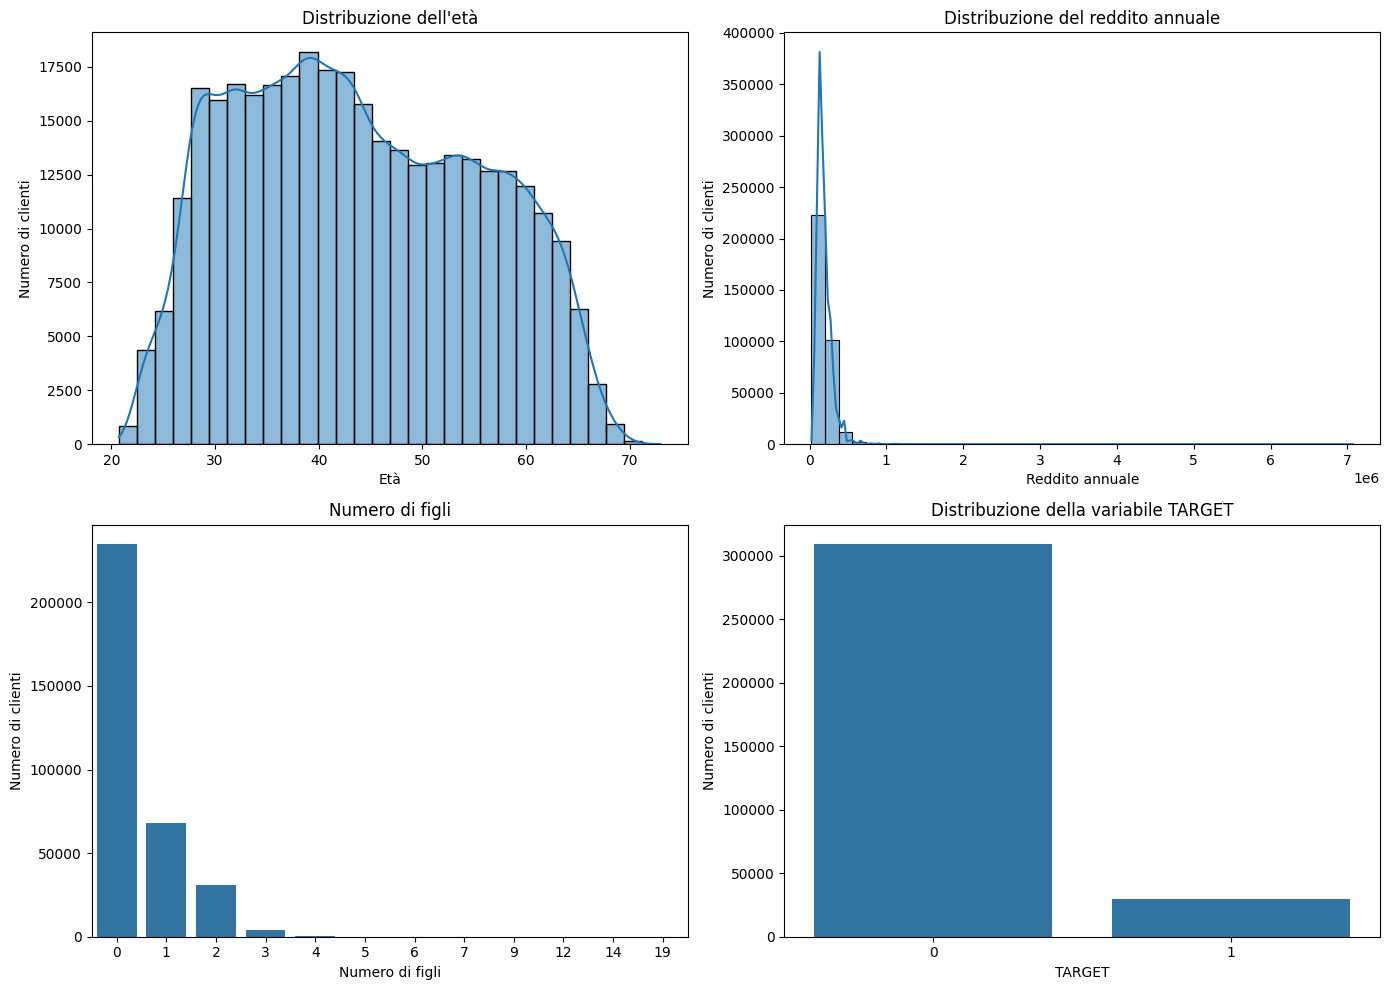

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribuzione dell'età
sns.histplot(
    data=df,
    x="AGE",
    bins=30,
    kde=True,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Distribuzione dell'età")
axes[0, 0].set_xlabel("Età")
axes[0, 0].set_ylabel("Numero di clienti")


# Distribuzione del reddito
sns.histplot(
    data=df,
    x="AMT_INCOME_TOTAL",
    bins=40,
    kde=True,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Distribuzione del reddito annuale")
axes[0, 1].set_xlabel("Reddito annuale")
axes[0, 1].set_ylabel("Numero di clienti")


# Numero di figli
sns.countplot(
    data=df,
    x="CNT_CHILDREN",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Numero di figli")
axes[1, 0].set_xlabel("Numero di figli")
axes[1, 0].set_ylabel("Numero di clienti")


# Distribuzione del target
sns.countplot(
    data=df,
    x="TARGET",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Distribuzione della variabile TARGET")
axes[1, 1].set_xlabel("TARGET")
axes[1, 1].set_ylabel("Numero di clienti")


plt.tight_layout()
plt.show()

**NOTA**: </br>
I grafici mostrano principalmente una popolazione composta da adulti tra i 30 e i 50 anni, con redditi concentrati su valori medio-bassi e una netta prevalenza di clienti senza figli. </br>
La variabile TARGET risulta sbilanciata verso lo 0, indicando che la maggioranza dei richiedenti ha una bassa affidabilità creditizia.

## **1.8 CONCLUSIONE EDA**

L’esplorazione del dataset mostra un database ricco e ben strutturato. La variabile TARGET risulta sbilanciata, quindi sarà necessario applicare tecniche di bilanciamento (class_weight, undersampling). </br>
Diverse variabili categoriche richiederanno encoding, mentre DAYS_BIRTH e DAYS_EMPLOYED necessitano di trasformazioni specifiche. </br>
Il dataset è ora pronto per la fase di preprocessing, che verrà sviluppata nella sezione successiva.

# **2. PREPROCESSING E FEATURE ENGINEERING**

Questa sezione ha l'obiettivo di preparare il dataset per l'addestramento dei modelli di machine learning. </br>
Nel dettaglio:
1.   separo le variabili esplicative dalla variabile target;
2.   individuo le variabili numeriche e categoriche;
3. trasformo le variabili categoriche in numeriche;
4. standardizzo le variabili numeriche;
5. costruisco un ColumnTransformer.



In [ ]:
x = df.drop("TARGET", axis=1)
y = df["TARGET"]

## **2.1 Separazione variabili numeriche e categoriche**


---
Divido le feature numeriche da quelle categoriche per applicare trasformazioni diverse.


In [ ]:
num_cols=x.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = x.select_dtypes(include=["object"]).columns.tolist()

In [ ]:
print("Variabili numeriche:")
print(num_cols)

Variabili numeriche:
['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE']


In [ ]:
print("Variabili categoriche:")
print(cat_cols)

Variabili categoriche:
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


## **2.2 Divisione tra training set e test set**

---
Prima di costruire il preprocessing divido i dati in training set e test set.


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,  #permette di mantenere lo sbilanciamento del target anche nel test set
    random_state= RANDOM_SEED
)

## **2.3 Costruzione delle pipeline di preprocessing**


---
Importo le librerie necessarie:


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

Creo la pipeline per le **variabili numeriche**, dove:
- sostituisco eventuali valori mancanti con la mediana.
- applico la standardizzazione.

In [ ]:
numeric_transformer= Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

Creo la pipeline per le **variabili categoriche**, dove:
- sostituisco eventuali valori mancanti con la categoria più frequente.
- applico lo one-hot encoding.

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

## **2.4 Costruzione del ColumnTransformer**

---
Ora unisco le 2 pipeline all'interno di un unico ColumnTransformer, il quale applica in auto:
- la pipeline numerica alle colonne contenute in `num_cols`;
- la pipeline categorica alle colonne contenute in `cat_cols`;


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,  num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

## **2.5 Completamento fase di Preprocessing**

---

Nell'ultimo step termino la fase di preprocessing mediante l'addestramento del TRAIN-SET e e applicato al test set per evitare data leakage.

Riassumento tramite FIT vado ada eseguire i seguenti steps:
- Imputazione dei valori mancanti;
- standardizzazione delle variabili numeriche;
- encoding delle variabili categoriche.

Grazie a ciò lo potrò applicare facilmente ai modelli di classificazione.   


In [ ]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

## **2.8 CONCLUSIONE PREPROCESSING**

In questa sezione ho preparato i dati per l'addestramento del modello. Ho separato la variabile target dalle variabili esplicative, distinto le variabili numeriche da quelle categoriche e costruito pipeline dedicate. Le variabili numeriche vengono imputate e standardizzate, mentre quelle categoriche vengono imputate e trasformate tramite One-Hot Encoding.

Infine ho unito il tutto nel ColumnTransformer, ottenendo i dataset preprocessati che verranno utilizzati per addestrare i modelli nella sezione successiva.

# **3. COSTRUZIONE DEI MODELLI DI CLASSIFICAZIONE**

In questa sezione costruisco i modelli di Machine Learning per prevedere l'affidabilità creditizia dei clienti.</br> Dato che il progetto richiede un modello spiegabile, il focus principale sarà sui modelli ad albero , affiancati da:  
- Regressione Logistica (come modello di confronto)
- Decision Tree
- Random Forest

Tutti i modelli verranno addestrati utilizzando i dati preprocessati nella Sezione 2.

**FUNZIONE DI VALUTAZIONE**

Definisco Metriche di Valutazione in un'unica funzione, che poi andrò a richiamare per tutti e 3 i modelli:

- **Classification Report** : Sintesi delle principali metriche di valutazione di un modello fìdi classificazione (Specify, Accuracy, Recall, Precision).
- **Matrice di Confusione** : Permette di sapere non solo quanti errori ha commesso il modello ma anche quali.

PS: *Per coerenza riutilizzo questa funzione perchè l'avevo già impiegata nel progetto di ML "Cross-Selling"*.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [ ]:
def evaluate_model(model, X, Y, model_name="Modello"):

    Y_pred = model.predict(X)
    Y_proba = model.predict_proba(X)[:, 1]

    accuracy = accuracy_score(Y, Y_pred)
    auc = roc_auc_score(Y, Y_proba)

    print(f"========== {model_name} ==========")

    print("\nCLASSIFICATION REPORT")
    print(classification_report(
            Y, Y_pred,
            target_names=["Non affidabile", "Affidabile"],
            zero_division=0
        )
    )

    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")

    # Matrice di confusione
    cm = confusion_matrix(Y, Y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predetto 0", "Predetto 1"],
        yticklabels=["Reale 0", "Reale 1"]
    )

    plt.title(f"Matrice di confusione - {model_name}")
    plt.xlabel("Classe predetta")
    plt.ylabel("Classe reale")
    plt.show()

**FUNZIONE DI VISUALIZZAZIONE ALBERI**

---
Questa funzione mi serve per visualizzare gli alberi nei modelli di Decision Tree e Random Forest.


In [ ]:
from sklearn.tree import export_graphviz, export_text
import graphviz
from IPython.display import display, Image

In [ ]:
def tree_viz(tree, feature_names=None, class_names=None):
  dot_data = export_graphviz(tree, out_file=None,
                        feature_names=feature_names,
                        class_names=class_names,
                        filled=True, rounded=True,
                        special_characters=True
                        )
  graph = graphviz.Source(dot_data, filename="tree", format="png")
  graph.view()
  display(Image("tree.png"))

## **3.1 Regressione Logistica**

---
In questa prima fase vado ad addestrare la regressione logistica utilizzando i dati preprocessati nella Sezione 2.
Questo modello lo utilizzo come punto di riferimento per confrontare i modelli ad albero.

In [ ]:
lr= LogisticRegression(class_weight="balanced",random_state= RANDOM_SEED)

PS : Uso `class_weight="balanced"` , perchè la variabile TARGET è fortemente sbilanciata.

In [ ]:
lr.fit(x_train_processed, y_train)

LogisticRegression(class_weight='balanced', random_state=0)

### **3.1.1 Predizione sul test set**

---
Dopo addestramento del train-set, genero le previsioni sul test-set.


In [ ]:
y_pred= lr.predict(x_test_processed)

In [ ]:
y_pred_proba =lr.predict_proba(x_test_processed)

In [ ]:
pd.Series(y_pred).value_counts()

,count
0,51247
1,16439


### **3.1.2 Valutazione del modello**

---
Procedo con la valutazione del modello di Regressione Logistica, usando la FUNZIONE DI VALUTAZIONE impostata all'inzio della sezione.

In [ ]:
print("Accuracy TRAIN:", lr.score(x_train_processed, y_train))
print("Accuracy TEST :", lr.score(x_test_processed, y_test))

Accuracy TRAIN: 0.8237534165620152
Accuracy TEST : 0.8265963419318618


**ACCURACY SCORE**:
- TRAIN_SET : 0.8238
- TEST_SET : 0.8266

La differenza tra train e test è minima → non si rileva overfitting.

========== Regressione Logistica ==========

CLASSIFICATION REPORT
                precision    recall  f1-score   support

Non affidabile       0.99      0.82      0.90     61742
    Affidabile       0.32      0.90      0.48      5944

      accuracy                           0.83     67686
     macro avg       0.66      0.86      0.69     67686
  weighted avg       0.93      0.83      0.86     67686

Accuracy: 0.8266
ROC-AUC:  0.9204


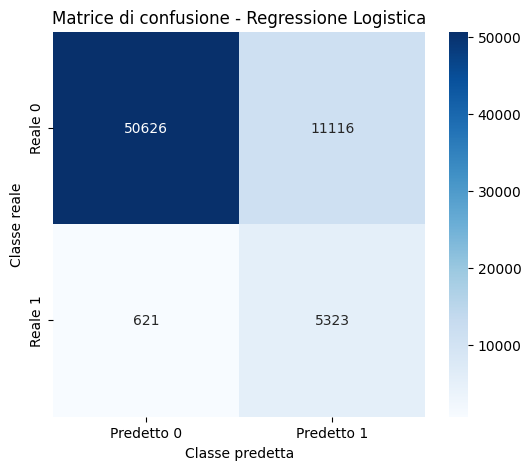

In [ ]:
evaluate_model(lr, x_test_processed, y_test, model_name="Regressione Logistica")

## **3.2 Decision Tree**

---
Ora che il preprocessing è stato completato, posso eseguire i seguenti steps :
- addestrare l'albero;
- leggere le regole decisionali;
- applicare eventuale pruning.

### **3.2.1 Addestramento dell'albero**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
tree_model = DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight='balanced')

In [ ]:
tree_model.fit(x_train_processed, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=0)

In [ ]:
y_pred=tree_model.predict(x_test_processed)
pd.Series(y_pred).value_counts()

,count
0,62068
1,5618


### **3.2.2 Valutazione del modello**

---
Procedo con la valutazione del modello di Decision Tree, usando la FUNZIONE DI VALUTAZIONE impostata all'inzio della sezione. Prima calcolo velocemente l'accuracy_score per verificare se il modello genera overfitting.

In [ ]:
print("Accuracy TRAIN:", tree_model.score(x_train_processed, y_train))
print("Accuracy TEST :", tree_model.score(x_test_processed, y_test))

Accuracy TRAIN: 1.0
Accuracy TEST : 0.9411104216529268


**ACCURACY SCORE**:
- TRAIN_SET : 1
- TEST_SET : 0.9411

Il modello mostra overfitting evidente: l’albero è troppo profondo e impara troppo bene il training set.

========== Decision Tree ==========

CLASSIFICATION REPORT
                precision    recall  f1-score   support

Non affidabile       0.97      0.97      0.97     61742
    Affidabile       0.67      0.64      0.66      5944

      accuracy                           0.94     67686
     macro avg       0.82      0.80      0.81     67686
  weighted avg       0.94      0.94      0.94     67686

Accuracy: 0.9411
ROC-AUC:  0.8038


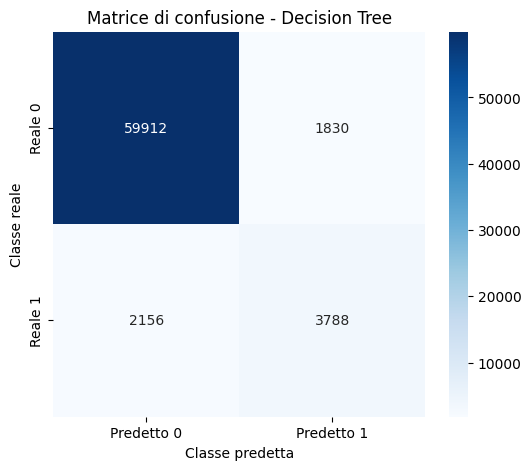

In [ ]:
evaluate_model(tree_model, x_test_processed, y_test, model_name="Decision Tree")

### **3.2.3 Visualizzazione dell'albero**

---
Ora posso visualizzare l'albero testuale, utilizzando i nomi delle features generati dal ColumnTransformer.

In [ ]:
feature_names = preprocessor.get_feature_names_out()

In [ ]:
print(export_text(tree_model,feature_names=list(feature_names)))

|--- num__AMT_INCOME_TOTAL <= -0.22
|   |--- num__AMT_INCOME_TOTAL <= -0.23
|   |   |--- num__AMT_INCOME_TOTAL <= -0.27
|   |   |   |--- num__AMT_INCOME_TOTAL <= -0.28
|   |   |   |   |--- cat__NAME_INCOME_TYPE_State servant <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- cat__NAME_INCOME_TYPE_State servant >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- num__AMT_INCOME_TOTAL >  -0.28
|   |   |   |   |--- num__AMT_INCOME_TOTAL <= -0.28
|   |   |   |   |   |--- cat__CODE_GENDER_F <= 0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- cat__CODE_GENDER_F >  0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__AMT_INCOME_TOTAL >  -0.28
|   |   |   |   |   |--- class: 0
|   |   |--- num__AMT_INCOME_TOTAL >  -0.27
|   |   |   |--- num__DAYS_EMPLOYED <= -0.46
|   |   |   |   |--- num__AGE <= -0.06
|   |   |   |   |   |--- num__AMT_INCOME_TOTAL <= -0.27
|   |   |   |   |   |   |--- num__AMT_INCOME_TOTAL <= -0.27
|   |   |   |   |   |   

L’albero non potato presenta una profondità elevata e una forte tendenza all’overfitting.

### **3.2.4 Pruning**

---
Per ridurre l’overfitting applico il pruning, limitando la profondità e il numero minimo di osservazioni per foglia.


In [ ]:
tree_model_pruned = DecisionTreeClassifier(
    random_state=RANDOM_SEED,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced"
)

**NOTE:**
Parametri utilizzati:
- `max_depth=10` : limita la profondità dell'albero;
- `min_samples_leaf=5` : stabilisce il numero minimo di osservazioni per foglia;
- `class_weight="balanced"` : considera lo sbilanciamento per classi;

In [ ]:
tree_model_pruned.fit(x_train_processed, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, random_state=0)

**Valutazione dopo pruning**

In [ ]:
print("Accuracy TRAIN dopo pruning:", tree_model_pruned.score(x_train_processed, y_train))
print("Accuracy TEST  dopo pruning:", tree_model_pruned.score(x_test_processed, y_test))

Accuracy TRAIN dopo pruning: 0.9489399423801433
Accuracy TEST  dopo pruning: 0.9482463138610643


**📊 Risultati PRE-POST PRUNING**
|            | PREPRUNING | POSTPRUNING |
|------------|------------|-------------|
| **TRAIN_SET** | 1.00 | 0.949 |
| **TEST_SET**  | 0.941 | 0.948 |

**COMMENTO** : Dopo avere applicato il pruining, abbiamo da un lato il miglioramento dell'accuracy del test-set (da 0.941 → 0.948) e lato train- set si riduce l'overfitting. Le perfomance risultano stabili e l'albero diventa + semplice e interpretabile.

## **3.3 Random Forest**

---
Passiamo al modello Random Forest, e fittiamolo con i dati preprocessati nella Sezione 2 seguendo i seguenti steps:  
- addestro l'albero;
- valuto il modello;
- lo visualizzo.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

### **3.3.1 Addestramento del Random Forest**

---
Per valutare l'effetto del numero di alberi (n_estimators) sulle performance, addestro diverse foreste con un nuero crescente di alberi.


In [ ]:
for n_tree in [1, 2, 3, 5, 10, 20, 50, 100]:
    print(f"Addestramento della foresta con {n_tree} alberi")

    forest = RandomForestClassifier(
        n_estimators=n_tree,
        random_state=RANDOM_SEED,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced"
    )
    forest.fit(x_train_processed,y_train)
    print(f"ACCURACY | TRAIN : {forest.score(x_train_processed, y_train):.3f}, TEST : {forest.score(x_test_processed, y_test):.3f}")

Addestramento della foresta con 1 alberi
ACCURACY | TRAIN : 0.836, TEST : 0.838
Addestramento della foresta con 2 alberi
ACCURACY | TRAIN : 0.926, TEST : 0.927
Addestramento della foresta con 3 alberi
ACCURACY | TRAIN : 0.921, TEST : 0.921
Addestramento della foresta con 5 alberi
ACCURACY | TRAIN : 0.929, TEST : 0.928
Addestramento della foresta con 10 alberi
ACCURACY | TRAIN : 0.947, TEST : 0.947
Addestramento della foresta con 20 alberi
ACCURACY | TRAIN : 0.949, TEST : 0.950
Addestramento della foresta con 50 alberi
ACCURACY | TRAIN : 0.949, TEST : 0.950
Addestramento della foresta con 100 alberi
ACCURACY | TRAIN : 0.949, TEST : 0.950


**COMMENTO** : La RF mostra un rapido miglioramento fino a 20 alberi, poi le performance si stabilizzano. Oltre il valore di 0.95, l'accuracy rimane invariata.

Pertanto 20 alberi rappresenta il miglior compromesso tra performance e costo computazionale.

In [ ]:
rf_model= RandomForestClassifier(
    n_estimators=20,
    random_state=RANDOM_SEED,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced"
)

In [ ]:
rf_model.fit(x_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=20, random_state=0)

### **3.3.2 Valutazione del modello**

In [ ]:
print("Accuracy TRAIN:", rf_model.score(x_train_processed, y_train))
print("Accuracy TEST :", rf_model.score(x_test_processed, y_test))

Accuracy TRAIN: 0.9493166875969565
Accuracy TEST : 0.9497237242561238


**ACCURACY SCORE**:
- TRAIN_SET : 0.949
- TEST_SET : 0.950

La differenza tra train e test è minima → overfitting ridotto.

========== Random Forest ==========

CLASSIFICATION REPORT
                precision    recall  f1-score   support

Non affidabile       1.00      0.95      0.97     61742
    Affidabile       0.64      0.99      0.78      5944

      accuracy                           0.95     67686
     macro avg       0.82      0.97      0.87     67686
  weighted avg       0.97      0.95      0.95     67686

Accuracy: 0.9497
ROC-AUC:  0.9773


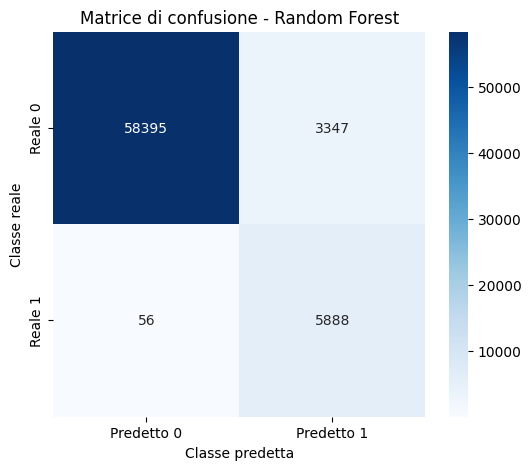

In [ ]:
evaluate_model(rf_model, x_test_processed, y_test, model_name="Random Forest")

## **3.4 Confronto Modelli di Classificazione**

---
A questo punto, confronto le performance dei 3 modelli addestrati:
- Regressione logistica
- Decision Tree
- Random Forest

Il confronto si basa sulle seguenti metriche: accuracy , stabilità tra train/test, overfitting, interpretabilità.


In [ ]:
print("----LOGISTIC REGRESSION----")
print("Accuracy TRAIN:", lr.score(x_train_processed, y_train))
print("Accuracy TEST :", lr.score(x_test_processed, y_test))

print("----PRUNED DECISION TREE----")
print("Accuracy TRAIN:", tree_model_pruned.score(x_train_processed, y_train))
print("Accuracy TEST :", tree_model_pruned.score(x_test_processed, y_test))

print("----RANDOM FOREST----")
print("Accuracy TRAIN:", rf_model.score(x_train_processed, y_train))
print("Accuracy TEST :", rf_model.score(x_test_processed, y_test))

----LOGISTIC REGRESSION----
Accuracy TRAIN: 0.8237534165620152
Accuracy TEST : 0.8265963419318618
----PRUNED DECISION TREE----
Accuracy TRAIN: 0.9489399423801433
Accuracy TEST : 0.9482463138610643
----RANDOM FOREST----
Accuracy TRAIN: 0.9493166875969565
Accuracy TEST : 0.9497237242561238


**TABELLA COMPARATIVA DELLE PERFORMANCE**
| Modello | Accuracy Train | Accuracy Test | Overfitting | Interpretabilità | Note |
|---|---:|---:|---|---|---|
| **Regressione Logistica** | 0.8238 | 0.8266 | **Basso** | Media | Baseline stabile |
| **Decision Tree** | 1.0000 | 0.9411 | **Alto** | Alta | Albero molto complesso, necessita pruning |
| **Decision Tree (Pruned)** | 0.9490 | 0.9480 | **Basso** | Alta | Migliora generalizzazione |
| **Random Forest (20 alberi)** | 0.9490 | 0.9500 | **Molto basso** | Media | Modello più stabile e performante |

**ANALISI COMPARATIVA:**

▶ **Regressione Logistica**:
- Funziona come baseline
- Performance stabile e senza overfitting
- Accuracy inferiore rispetto ai modelli ad Albero
-Interpretabilità limitata alle relazioni lineari

▶ **Decision Tree Pruned**:
- Riduce l’overfitting (train: 1.00 → 0.949).
- Migliora la generalizzazione (test: 0.941 → 0.948).
- Albero più semplice e leggibile-> coem richiesto dal punto Bonus del progetto è l a+ interpretabile

▶ **Random Forest**:
- Miglior compromesso tra performance e costo computazionale.
- Accuracy train/test quasi identica → overfitting minimo.
- Performance migliori tra tutti i modelli.

## **3.5 RISULTATO 🎯- Scelta Finale del Modello**

In base ai risultati ottenuti e sulla necessità di fornire indicazioni facilmente interpretabili, la scelta finale per stimare l’affidabilità creditizia dei clienti ricade sul:<br>

 ⭐**DECISION TREE (Pruined)**⭐

### **3.5.1 Visualizzazione DECISION TREE**
---


Visualizzo il Decision Tree pruned, che rappresenta il modello interpretabile utilizzato per fornire motivazioni chiare al cliente.

In [ ]:
feature_names = preprocessor.get_feature_names_out()

In [ ]:
class_names = ["Non affidabile", "Affidabile"]

tree_viz(
    tree_model_pruned,
    feature_names=list(feature_names),
    class_names=class_names
)

Nonostante l'applicazione del pruning, l'albero decisionale mantiene una struttura articolata. </br>
Questo comportamento penso che sia normale a causa della complessità del dataset, formato da molte variabili e categorie.

### 3.5.2 **Decision Tree Super Interpretabile**

Per ottenere una versione ancora più leggibile, costruisco un secondo albero con profondità limitata.

In [ ]:
tree_model_super = DecisionTreeClassifier(
    random_state=RANDOM_SEED,
    max_depth=3,
    min_samples_leaf=20,
    min_samples_split=40,
    class_weight="balanced"
)

In [ ]:
tree_model_super.fit(x_train_processed, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=3,
                       min_samples_leaf=20, min_samples_split=40,
                       random_state=0)

In [ ]:
print("Accuracy TRAIN:", tree_model_super.score(x_train_processed, y_train))
print("Accuracy TEST :", tree_model_super.score(x_test_processed, y_test))

Accuracy TRAIN: 0.9478761911797297
Accuracy TEST : 0.9487486333953846


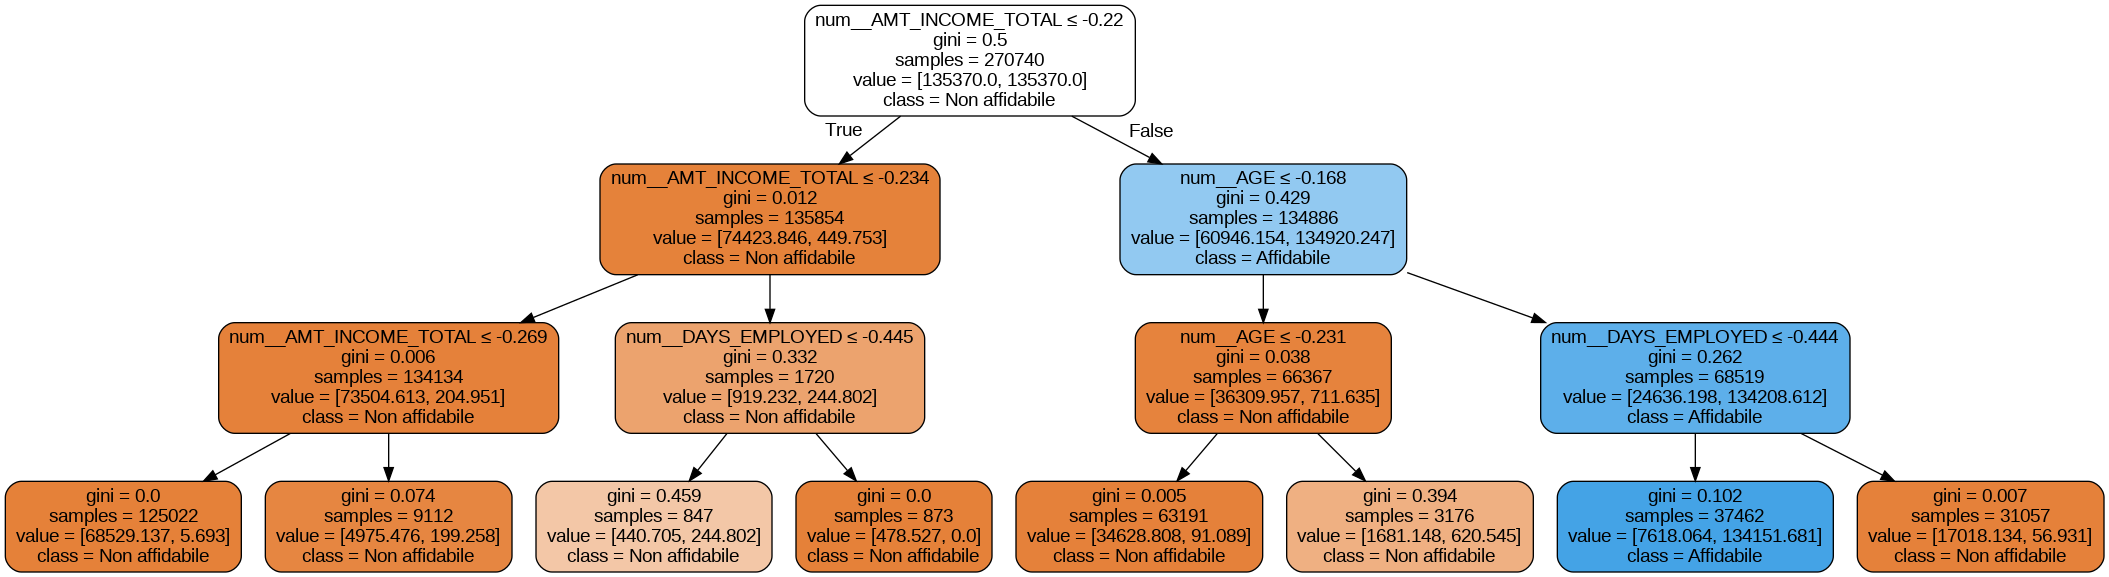

In [ ]:
feature_names = preprocessor.get_feature_names_out()
class_names = ["Non affidabile", "Affidabile"]

tree_viz(
    tree_model_super,
    feature_names=list(feature_names),
    class_names=class_names
)

**NOTE** : Il modello appena generato presenta una struttura molto + compatta e leggibile rispetto ai precedenti, grazie al numero limitato di rami e foglie.</br>
La sua accuratezza è leggermente inferiore (0.948 vs 0.950), ma la sua semplicità lo rende ideale per fornire motivazioni chiare e comprensibili al cliente.

# **4. CONCLUSIONE E SPIEGAZIONE MODELLO**

In questo progetto ho costrutito diversi modelli per stimare l'affidabilità creditizia dei clienti.

Dopo il confronto tra Regressione Logistica, Decision Tree e Random Forest, la scelta finale è ricaduta sul:

⭐ **Decision Tree (Pruned)**⭐ </br>
perchè il modello è più facile da leggere e da spiegare rispetto alla Random Forest.

---
La Random Forest ha performance leggermente migliori, ma non permette di visualizzare un singolo percorso decisionale.


## **4.1 Spiegazione del modello**

Il Decision Tree pruned utilizza alcune variabili chiave (in versione standardizzata) per distinguere i clienti affidabili da quelli meno affidabili.

Il percorso che porta alla classe `Affidabile` segue 3 condizioni:
1. **Reddito annuale sopra una certa soglia** | `AMT_INCOME <= -0.22`
2. **Età sopra un certa soglia** | `AGE <= -0.168`  
3. **Anzianità lavorativa elevata** | `DAYS_EMPLOYED <= -0.168`  

*In pratica Reddito alto + età adulta + lavoro stabile -> cliente Affidabile*

## **4.2 Esempio pratico**

---
Per concludere l'analisi, applico il modello finale a un cliente del test set. </br>
Gli step sono :    
- Seleziono un cliente del test_set;
- Applico il modello;
- Stampo la predizione e la probabilità associata


In [ ]:
client = x_test_processed[0:1]

In [ ]:
prediction = tree_model_super.predict(client)
prob =   tree_model_super.predict_proba(client)

In [ ]:
prediction_class = prediction[0]
aff = prob[0, prediction_class] * 100

if prediction_class == 0:
    print(f"Il cliente è considerato NON affidabile (probabilità: {aff:.2f}%)")
else:
    print(f"Il cliente è considerato AFFIDABILE (probabilità: {aff:.2f}%)")

Il cliente è considerato NON affidabile (probabilità: 99.74%)


Questo semplice esempio mostra come il modello possa produrre una previsione per un singolo cliente e associare a tale previsione una probabilità stimata.